The Challenge: > Given three ciphertexts generated from the same (unknown) plaintext using three different encryption schemes, the relationship between each scheme and its corresponding ciphertext is unknown. We are given that the block size is 5
The encryption schemes used are:

- Vigenère cipher

- Hill Cipher

- Some  advanced encryption scheme

Objectives:

- Discover the plaintext

- Find the keys and coressponds ciphertext of the  Vigenère and Hill Ciphers

- Decrypt secret message that encrypted by the third cipher

In the first stage, our goal is to crack one of the ciphers and discover the plaintext. Among the ciphers, the Vigenère cipher seemed to us the easiest to identify and break, so we tried to determine which of the files corresponds to this cipher. To do this, we decided to examine the letter distributions. Of course, the shifts for each index in the key are different, so we need to split the text according to the key length. Letters that underwent the same shift should give us a distribution identical to the letter distribution in the English language (except for a shift of the letters). We know that the block size (i.e., the key length) is 5, so we divided the letters into groups based on their positions, where letters with the same position modulo 5 are in the same group (meaning they underwent the same shift).

We started with file 1, divided the letters in the text into groups, and printed a histogram for each group:

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from sympy import Matrix, pprint

In [ ]:
BLOCK_SIZE = 5

In [ ]:
# read data from files
f = open("file1.txt" , "r")
text1 = f.read()
# read data from files
f = open("file2.txt" , "r")
text2 = f.read()
# read data from files
f = open("file3.txt" , "r")
text3 = f.read()

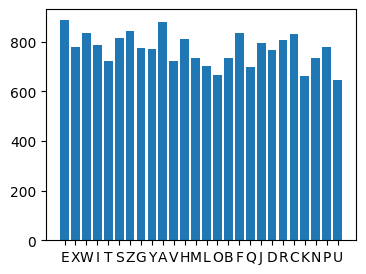

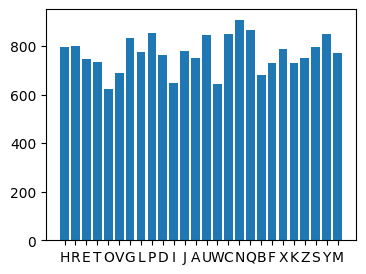

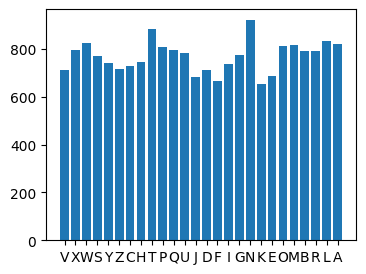

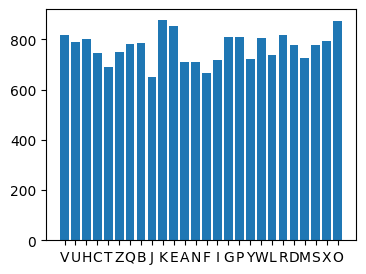

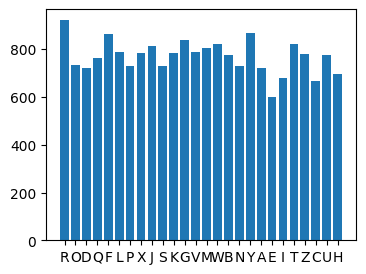

In [ ]:
# divide to groups acorrding to apropriate index (by block size of 5)
data =  {0:[], 1:[], 2:[], 3:[], 4:[]}

for i in range(len(text1)):
    data[i%BLOCK_SIZE].append(text1[i])

# find letters distribution
counters = {0:[], 1:[], 2:[], 3:[], 4:[]}
most_common = [0, 0, 0, 0, 0]

# plots
for i in range(BLOCK_SIZE):
    counters[i] = Counter(data[i])
    most_common[i] = counters[i].most_common(1)[0][0]
    plt.figure(figsize = (4,3))
    plt.bar(counters[i].keys(),counters[i].values())
    plt.show()

It can be seen that the histograms do not resemble the letter distribution graph of the English language. Therefore, this file was most likely not encrypted using the Vigenère cipher.

Let's move on to examine the second file:

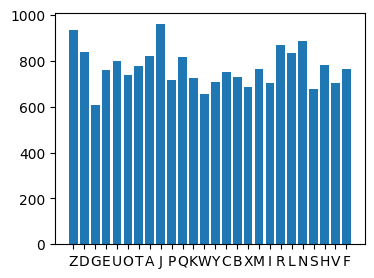

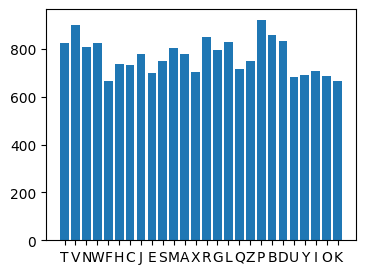

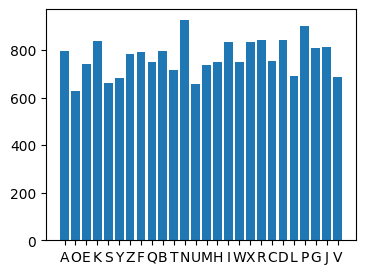

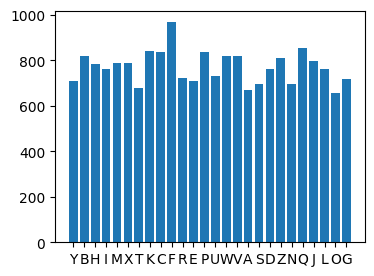

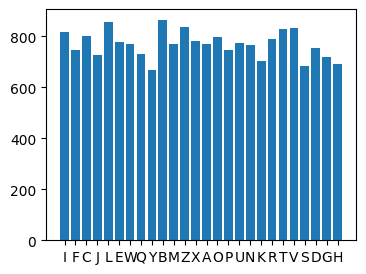

In [43]:
# divide to groups acorrding to apropriate index (by block size of 5)
data =  {0:[], 1:[], 2:[], 3:[], 4:[]}

for i in range(len(text2)):
    data[i%BLOCK_SIZE].append(text2[i])

# find letters distribution
counters = {0:[], 1:[], 2:[], 3:[], 4:[]}
most_common = [0, 0, 0, 0, 0]

# plot
for i in range(BLOCK_SIZE):
    counters[i] = Counter(data[i])
    most_common[i] = counters[i].most_common(1)[0][0]
    plt.figure(figsize = (4,3))
    plt.bar(counters[i].keys(),counters[i].values())
    plt.show()

Again, the letter distribution graph isn't match to the English language letter distribution.

Let's try the third file:

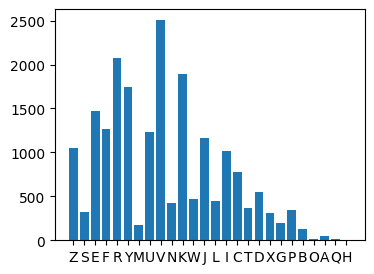

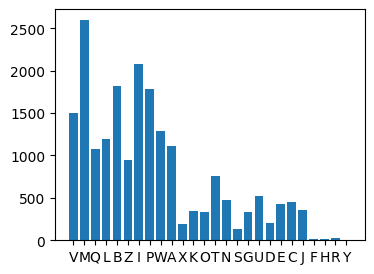

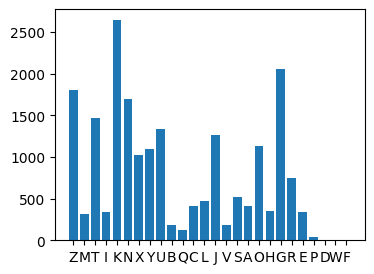

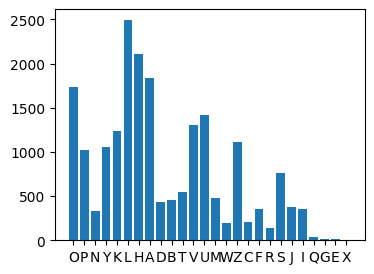

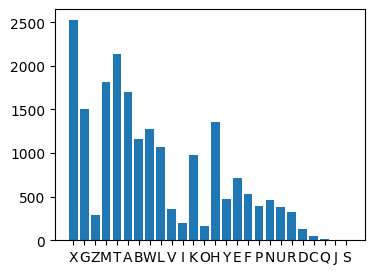

In [44]:
# divide to groups acorrding to apropriate index (by block size of 5)
data =  {0:[], 1:[], 2:[], 3:[], 4:[]}

for i in range(len(text3)):
    data[i%BLOCK_SIZE].append(text3[i])

# find letters distribution
counters = {0:[], 1:[], 2:[], 3:[], 4:[]}
most_common = [0, 0, 0, 0, 0]

# plot
for i in range(BLOCK_SIZE):
    counters[i] = Counter(data[i])
    most_common[i] = counters[i].most_common(1)[0][0]
    plt.figure(figsize = (4,3))
    plt.bar(counters[i].keys(),counters[i].values())
    plt.show()


In this case, the letter distributions appear to match the expected distribution of letters in the English language. Therefore, we conclude that this file was likely encrypted using the Vigenère cipher!

We know that the most frequent letter in the English language is E. Therefore, we take the most frequent letter in each distribution and assume it corresponds to E. Using this assumption, we calculate the shift—i.e., determine the key at that index.

Next, we attempt to decrypt the text using the estimated key and check whether the result is a meaningful plaintext.

for index 1 the most common letter is V so the shift from E is 17

for index 2 the most common letter is M so the shift from E is 8

for index 3 the most common letter is K so the shift from E is 6

for index 4 the most common letter is L so the shift from E is 7

for index 5 the most common letter is X so the shift from E is 19

so the key is:
### "RIGHT"

In [45]:
# Key array containing the shift values for each position
key = [17, 8, 6, 7, 19]
plaintext = []

# Subtract the shift (from the key) for the current character
for i in range(len(text3)):
    plaintext.append(ord(text3[i]) - key[i%BLOCK_SIZE] )  
    # Normalize to A-Z range
    if (plaintext[i] < 65):
        plaintext[i]  = plaintext[i]  + 26
    plaintext[i] = chr(plaintext[i])

# Join the list of characters into a final string
plaintext = ''.join(plaintext)
print(plaintext)

...


We discovered that the plaintext is a passage from the Bible! 

Now we can use it to help decode the other ciphers

we are left with File 1 and File 2, and we aim to decrypt one of them using the Hill Cipher.
We already have the plaintext (since the encrypted message is the same for all files), and we also have the ciphertext, so the only thing missing is the key.

We know that the encryption in Hill Cipher is performed as:
P × K = C, where:

P is the plaintext matrix,

K is the key matrix,

C is the ciphertext matrix.

Since we are working with matrices, we chose to divide the message into blocks of 5 letters (like the block size), and work with 5×5 matrices.
This allows us to compute the key using the formula:
K = (P⁻¹ × C) mod 26,
as long as the plaintext matrix is invertible modulo 26.

By doing this, we hope to recover the key matrix K and use it to decrypt the message.


We take the first 25 characters of the discovered plaintext, convert them to numbers using the ASCII table, then transpose the resulting matrix and attempt to invert it modulo 26:

In [46]:
ordplaintext1 = []
for i in plaintext[0:25]:
    ordplaintext1.append(ord(i) - 65)

p1_matrix = [list(ordplaintext1[i:i+BLOCK_SIZE]) for i in range(0, len(ordplaintext1), BLOCK_SIZE)]
p1_matrix = Matrix(p1_matrix)
p1_matrix = p1_matrix.T
p1_matrix_inv = p1_matrix.inv_mod(26)

NonInvertibleMatrixError: Matrix is not invertible (mod 26)

We can see that the first 25 characters of the plaintext do not form an invertible matrix, so we'll try the next 25 characters instead.

In [ ]:
ordplaintext = []
for i in plaintext[25:50]:
    ordplaintext.append(ord(i) - 65)

p_matrix = [list(ordplaintext[i:i+BLOCK_SIZE]) for i in range(0, len(ordplaintext), BLOCK_SIZE)]
p_matrix = Matrix(p_matrix)
p_matrix = p_matrix.T
p_matrix_inv = p_matrix.inv_mod(26)


We successfully inverted the matrix built from the second set of 25 characters in the plaintext. Next, we construct matrices from the corresponding 25 characters in the ciphertexts of files 1 and 2. Instead of converting the decrypted result back to text, we multiply the plaintext matrix by the derived key and compare the result to the ciphertext matrices (modulo 26). If one of them matches, we can conclude that the key is correct and that the corresponding file was encrypted using the Hill Cipher.

In [ ]:
ordplaintext = []
for i in plaintext[0:25]:
    ordplaintext.append(ord(i) - 65)
    
p_matrix = [list(ordplaintext[i:i+BLOCK_SIZE]) for i in range(0, len(ordplaintext), BLOCK_SIZE)]
p_matrix = Matrix(p_matrix)
p_matrix = p_matrix.T

In [ ]:
ordciphertext1 = []
for i in text1[25:50]:
    ordciphertext1.append(ord(i) - 65)
c1_matrix = [list(ordciphertext1[i:i+BLOCK_SIZE]) for i in range(0, len(ordciphertext1), BLOCK_SIZE)]
c1_matrix = np.array(c1_matrix)
c1_matrix = c1_matrix.transpose()
   
k1 = c1_matrix * p_matrix_inv
k1 = k1.applyfunc(lambda x: x % 26)


In [34]:
c1 = k1 * p1_matrix 
c1 = c1.applyfunc(lambda x: x % 26)
pprint(c1)

⎡18  5   16  2   3 ⎤
⎢                  ⎥
⎢20  11  6   0   17⎥
⎢                  ⎥
⎢25  9   13  0   17⎥
⎢                  ⎥
⎢3   10  5   21  22⎥
⎢                  ⎥
⎣13  14  5   22  12⎦


In [47]:
ordciphertext1 = []
for i in text1[0:25]:
    ordciphertext1.append(ord(i) - 65)
c1_matrix = [list(ordciphertext1[i:i+BLOCK_SIZE]) for i in range(0, len(ordciphertext1), BLOCK_SIZE)]
c1_matrix = np.array(c1_matrix)
c1_matrix = c1_matrix.transpose()
pprint(c1_matrix)

[[ 4 23 22  8 19] 
 [ 7 17  4  7 19] 
 [21 23 22 18 24] 
 [21 20  7  2 19] 
 [17 14  3 16  5]]


It is clear that the matrices are not identical, so we will proceed to test file 2:


In [49]:
ordciphertext2 = []
for i in text2[25:50]:
    ordciphertext2.append(ord(i) - 65)
c2_matrix = [list(ordciphertext2[i:i+BLOCK_SIZE]) for i in range(0, len(ordciphertext2), BLOCK_SIZE)]
c2_matrix = np.array(c2_matrix)
c2_matrix = c2_matrix.transpose()

k2 = c2_matrix * p_matrix_inv
k2 = k2.applyfunc(lambda x: x % 26)

In [50]:
c2 = k2 * p1_matrix 
c2 = c2.applyfunc(lambda x: x % 26)
pprint(c2)

⎡25  3   6   4   20⎤
⎢                  ⎥
⎢19  21  13  22  5 ⎥
⎢                  ⎥
⎢0   14  0   4   10⎥
⎢                  ⎥
⎢24  1   7   8   12⎥
⎢                  ⎥
⎣8   5   2   9   11⎦


In [51]:
ordciphertext2 = []
for i in text2[0:25]:
    ordciphertext2.append(ord(i) - 65)
c2_matrix = [list(ordciphertext2[i:i+BLOCK_SIZE]) for i in range(0, len(ordciphertext2), BLOCK_SIZE)]
c2_matrix = np.array(c2_matrix)
c2_matrix = c2_matrix.transpose()
pprint(c2_matrix)

[[25  3  6  4 20] 
 [19 21 13 22  5] 
 [ 0 14  0  4 10] 
 [24  1  7  8 12] 
 [ 8  5  2  9 11]]


In [52]:
pprint(k2)


⎡3   4   1   20  6 ⎤
⎢                  ⎥
⎢6   8   13  6   5 ⎥
⎢                  ⎥
⎢14  17  4   21  4 ⎥
⎢                  ⎥
⎢17  13  4   21  4 ⎥
⎢                  ⎥
⎣17  4   13  3   18⎦


Now the matrices are identical, which means the Hill Cipher corresponds to file 2!

### and the key is: 
⎡3  4   1   20  6 ⎤
                  

⎢6   8   13  6   5 ⎥
                  

⎢14  17  4   21  4 ⎥
                  

⎢17  13  4   21  4 ⎥
                  

⎣17  4   13  3   18⎦

After deciphering the first two ciphers, we now know that the file text1 is the one that was encrypted by the assistant. Although we don’t know which cipher was used, we do know that this encryption also uses blocks of size 5. We broke the assistant’s secret message into four blocks of size 5: 'PROFA', 'CSHIO', 'VCWAL', 'IYPSK', and searched for each block in the encrypted text in file1. When we found a match — we looked for the corresponding decryption in the same location in the plaintext.
We then concatenated the decrypted parts to obtain the message left by the assistant.

In [53]:
wordsfound = [0,0,0,0]
for i in range(int(len(text1)/5)):
    if text1[(5 * i):(5 * i + 5)] == "PROFA":
        wordsfound[0] = plaintext[(5 * i):(5 * i + 5)]
    if text1[(5 * i):(5 * i + 5)] == "CSHIO":
        wordsfound[1] = plaintext[(5 * i):(5 * i + 5)]  
    if text1[(5 * i):(5 * i + 5)] == "VCWAL":
        wordsfound[2] = plaintext[(5 * i):(5 * i + 5)]  
    if text1[(5 * i):(5 * i + 5)] == "IYPSK":
        wordsfound[3] = plaintext[(5 * i):(5 * i + 5)]  
        
secret_message = ''.join(wordsfound)    
    

In [54]:
print(secret_message)

ITWASTHEENEMYBROTHER


We discover the secret message of the assistant: 
### ‘It was the enemy brother'